In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!pip install onnx onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.4 MB/s eta 0:00:00


In [19]:
import os
import glob
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DATA_DIR = "/content/drive/MyDrive/data"
SELECTED_ACTIVITIES = ["sit", "walk", "run", "stairs"]

TRAIN_POSITIONS = ["dom_hand"]
TEST_POSITIONS = ["nondom_hand"]

SAMPLING_RATE = 100
TRIM_SECONDS = 2
WINDOW_SIZE = SAMPLING_RATE
STEP_SIZE = SAMPLING_RATE // 2

BATCH_SIZE = 32
EPOCHS = 100
LR = 0.001
DROPOUT = 0.3
RANDOM_STATE = 42
EPSILON = 1e-7

GFT_FEATURES = ["ax_g", "ay_g", "az_g", "gx_g", "gy_g", "gz_g"]

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

In [3]:
def load_selected_csvs(base_dir):
    dfs = []
    all_positions = list(set(TRAIN_POSITIONS + TEST_POSITIONS))
    for activity in SELECTED_ACTIVITIES:
        for position in all_positions:
            path = os.path.join(base_dir, activity, position, "*.csv")
            for csv_path in glob.glob(path):
                try:
                    df = pd.read_csv(csv_path)
                    df["activity"] = activity
                    df["phone_position"] = position
                    df["recording_id"] = os.path.splitext(os.path.basename(csv_path))[0]
                    dfs.append(df)
                except Exception as e:
                    print(f"Error loading {csv_path}: {e}")
    print(f"Loaded {len(dfs)} recordings.")
    return dfs

def trim_df(df):
    trim = SAMPLING_RATE * TRIM_SECONDS
    if len(df) <= 2 * trim:
        return None
    return df.iloc[trim:-trim].reset_index(drop=True)

def sliding_windows(df):
    for start in range(0, len(df) - WINDOW_SIZE + 1, STEP_SIZE):
        yield df.iloc[start:start + WINDOW_SIZE]

def build_dataset(dfs, feature_cols):
    X, y, groups = [], [], []
    for df in dfs:
        df = trim_df(df)
        if df is None:
            continue
        for w in sliding_windows(df):
            X.append(w[feature_cols].values)
            y.append(w["activity"].iloc[0])
            groups.append(w["recording_id"].iloc[0])
    if len(X) == 0:
        return np.array([]), np.array([]), np.array([])
    return np.array(X), np.array(y), np.array(groups)

class MotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
class SinusoidalPositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1), :].unsqueeze(0)

class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride=1, expand_ratio=4):
        super().__init__()
        hidden_dim = int(inp * expand_ratio)
        self.use_res_connect = (inp == oup)
        self.block = nn.Sequential(
            nn.Conv1d(inp, hidden_dim, 1, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_dim, hidden_dim, 3, stride=stride, padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_dim, oup, 1, bias=False),
            nn.BatchNorm1d(oup)
        )

    def forward(self, x):
        if self.use_res_connect:
            return x + self.block(x)
        else:
            return self.block(x)

class MobileHARTBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = InvertedResidual(in_channels, out_channels)
    def forward(self, x):
        return self.block(x)

class MobileTransformer(nn.Module):
    def __init__(self, num_features, num_classes, dropout=0.3):
        super().__init__()
        self.acc_block = MobileHARTBlock(3, 32)
        self.gyro_block = MobileHARTBlock(3, 32)

        self.fusion_conv = nn.Conv1d(64, 64, kernel_size=1)
        self.bn_fusion = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.pos_emb = SinusoidalPositionalEmbedding(d_model=64, max_len=WINDOW_SIZE)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64, nhead=2, dim_feedforward=128, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        acc = x[:, :, :3].permute(0, 2, 1)
        gyro = x[:, :, 3:].permute(0, 2, 1)

        acc_feat = self.acc_block(acc)
        gyro_feat = self.gyro_block(gyro)

        fused = torch.cat([acc_feat, gyro_feat], dim=1)
        fused = self.relu(self.bn_fusion(self.fusion_conv(fused)))
        fused = fused.permute(0, 2, 1)
        fused = self.pos_emb(fused)
        x_trans = self.transformer(fused)
        x_trans = x_trans.permute(0, 2, 1)
        x_pooled = self.gap(x_trans).squeeze(-1)
        x_pooled = self.dropout(x_pooled)
        return self.fc(x_pooled)

In [21]:
def run_cross_position_experiment(all_dfs, feature_cols, title_suffix):
    train_dfs = [df for df in all_dfs if df["phone_position"].iloc[0] in TRAIN_POSITIONS]
    test_dfs = [df for df in all_dfs if df["phone_position"].iloc[0] in TEST_POSITIONS]

    X_full_train, y_full_train, g_full_train = build_dataset(train_dfs, feature_cols)
    X_test, y_test, _ = build_dataset(test_dfs, feature_cols)

    le = LabelEncoder()
    le.fit(SELECTED_ACTIVITIES)
    y_full_train_enc = le.transform(y_full_train)
    y_test_enc = le.transform(y_test)

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    train_idx, val_idx = next(splitter.split(X_full_train, y_full_train_enc, g_full_train))
    X_train, y_train = X_full_train[train_idx], y_full_train_enc[train_idx]
    X_val, y_val = X_full_train[val_idx], y_full_train_enc[val_idx]

    scaler = StandardScaler()
    N_train, T, F = X_train.shape
    X_train = scaler.fit_transform(X_train.reshape(-1, F)).reshape(N_train, T, F)
    X_val = scaler.transform(X_val.reshape(-1, F)).reshape(X_val.shape[0], T, F)
    X_test = scaler.transform(X_test.reshape(-1, F)).reshape(X_test.shape[0], T, F)

    scaler_mean = scaler.mean_
    scaler_std = scaler.scale_

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MobileTransformer(num_features=X_train.shape[2], num_classes=len(le.classes_)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=10)

    train_loader = DataLoader(MotionDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(MotionDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

    best_loss = np.inf
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} - Val Loss: {val_loss:.4f}")

    model.load_state_dict(best_state)

    model.eval()
    test_loader = DataLoader(MotionDataset(X_test, y_test_enc), batch_size=BATCH_SIZE, shuffle=False)
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            out = model(xb)
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    print(f"\n=== Classification Report: {title_suffix} ===")
    print(classification_report(trues, preds, target_names=le.classes_, digits=4))

    cm = confusion_matrix(trues, preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Oranges")
    plt.title(f"{title_suffix}\nTrain: {TRAIN_POSITIONS} -> Test: {TEST_POSITIONS}")
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

    dummy_input = torch.randn(1, WINDOW_SIZE, 6).to(device)
    onnx_path = "model.onnx"
    torch.onnx.export(
        model,
        dummy_input,
        onnx_path,
        input_names=["X"],
        output_names=["logits"],
        dynamic_axes={"X": {0: "batch", 1: "time"}},
        opset_version=17
    )
    print(f"Exported ONNX model to {onnx_path}")

    json.dump({
        "mean": scaler_mean.tolist(),
        "std": (scaler_std + EPSILON).tolist(),
        "labels": le.classes_.tolist()
    }, open("model.json", "w"))
    print("Saved scaler stats and labels to model.json")

Loaded 40 recordings.
Epoch 10/100 - Val Loss: 0.4302
Epoch 20/100 - Val Loss: 0.4477
Epoch 30/100 - Val Loss: 0.4516
Epoch 40/100 - Val Loss: 0.4332
Epoch 50/100 - Val Loss: 0.4367
Epoch 60/100 - Val Loss: 0.4391
Epoch 70/100 - Val Loss: 0.4430
Epoch 80/100 - Val Loss: 0.4551
Epoch 90/100 - Val Loss: 0.4465
Epoch 100/100 - Val Loss: 0.4536

=== Classification Report: MobileHART – GFT Features Only + ONNX ===
              precision    recall  f1-score   support

         run     0.6281    1.0000    0.7716       250
         sit     0.9538    0.9920    0.9725       250
      stairs     1.0000    0.0157    0.0309       255
        walk     0.6968    0.9560    0.8061       250

    accuracy                         0.7373      1005
   macro avg     0.8197    0.7409    0.6453      1005
weighted avg     0.8206    0.7373    0.6422      1005



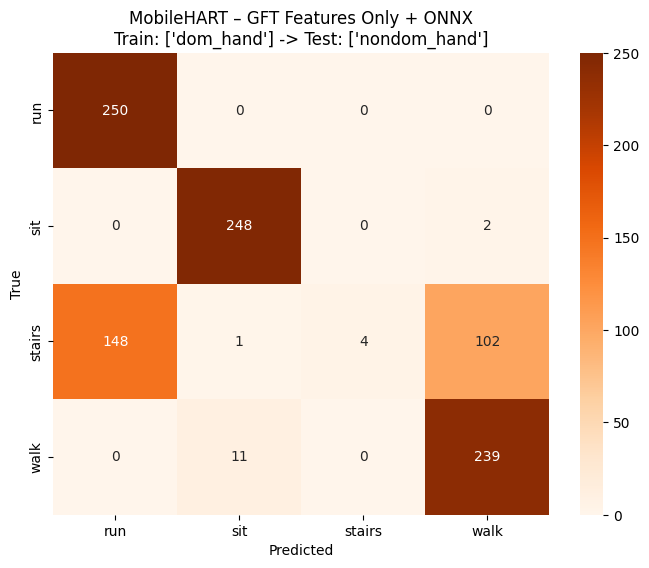

/tmp/ipython-input-25586769.py:88: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0201 16:54:40.793000 332 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MobileTransformer([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileTransformer([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Applied 30 of general pattern rewrite rules.
Exported ONNX model to model.onnx
Saved scaler stats and labels to model.json


In [22]:
if __name__ == "__main__":
    all_recordings = load_selected_csvs(DATA_DIR)
    if all_recordings:
        run_cross_position_experiment(all_recordings, GFT_FEATURES, "MobileHART – GFT Features Only + ONNX")